# Titulo 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [29]:
# Países com mais jogadores valiosos (top 10% em valor de mercado)
players = pd.read_csv(r"football\players.csv")

players = players.dropna(subset=['country_of_birth', 'market_value_in_eur'])
threshold = players['market_value_in_eur'].quantile(0.90)
valuable_players = players[players['market_value_in_eur'] >= threshold]

country_counts = (
    valuable_players.groupby('country_of_birth', as_index=False)
    .agg(n_valiosos=('player_id', 'size'), avg_market_value=('market_value_in_eur', 'mean'))
    .sort_values(['n_valiosos', 'avg_market_value'], ascending=[False, False])
)

country_counts.head(15)

,country_of_birth,n_valiosos,avg_market_value
38,France,351,1.466610e+07
10,Brazil,341,1.192287e+07
106,Spain,298,1.396879e+07
34,England,286,1.844580e+07
42,Germany,227,1.294714e+07
3,Argentina,221,9.601810e+06
81,Netherlands,158,1.405506e+07
58,Italy,158,1.372532e+07
6,Belgium,127,1.137008e+07
90,Portugal,126,1.441429e+07


C:\Users\Lucas Marum\AppData\Local\Temp\ipykernel_8976\2144294392.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_counts.head(10), x='n_valiosos', y='country_of_birth', palette='viridis')


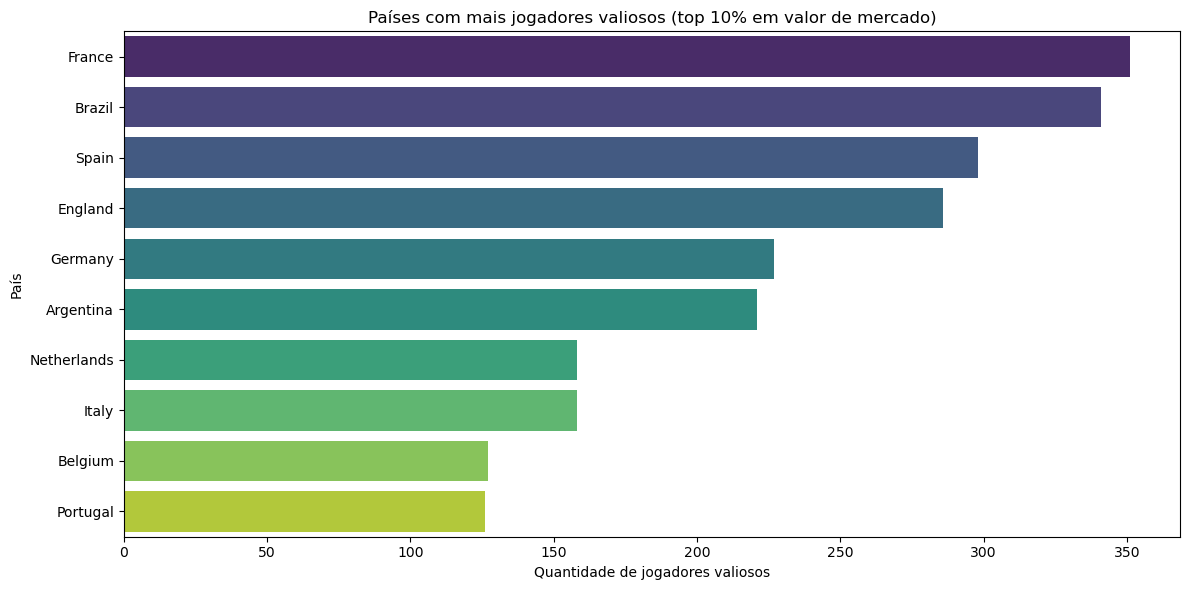

In [31]:
# Países com mais jogadores valiosos (top 10% em valor de mercado)
players = pd.read_csv(r"football\players.csv")

players = players.dropna(subset=['country_of_birth', 'market_value_in_eur'])
threshold = players['market_value_in_eur'].quantile(0.90)
valuable_players = players[players['market_value_in_eur'] >= threshold]

country_counts = (
    valuable_players.groupby('country_of_birth', as_index=False)
    .agg(n_valiosos=('player_id', 'size'), avg_market_value=('market_value_in_eur', 'mean'))
    .sort_values(['n_valiosos', 'avg_market_value'], ascending=[False, False])
)

country_counts.head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=country_counts.head(10), x='n_valiosos', y='country_of_birth', palette='viridis')
plt.title('Países com mais jogadores valiosos (top 10% em valor de mercado)')
plt.xlabel('Quantidade de jogadores valiosos')
plt.ylabel('País')
plt.tight_layout()
plt.show()

C:\Users\Lucas Marum\AppData\Local\Temp\ipykernel_8976\1053929388.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=pib_selecionados, x='GDP per capita', y='País', palette='viridis', order=pib_selecionados['País'])


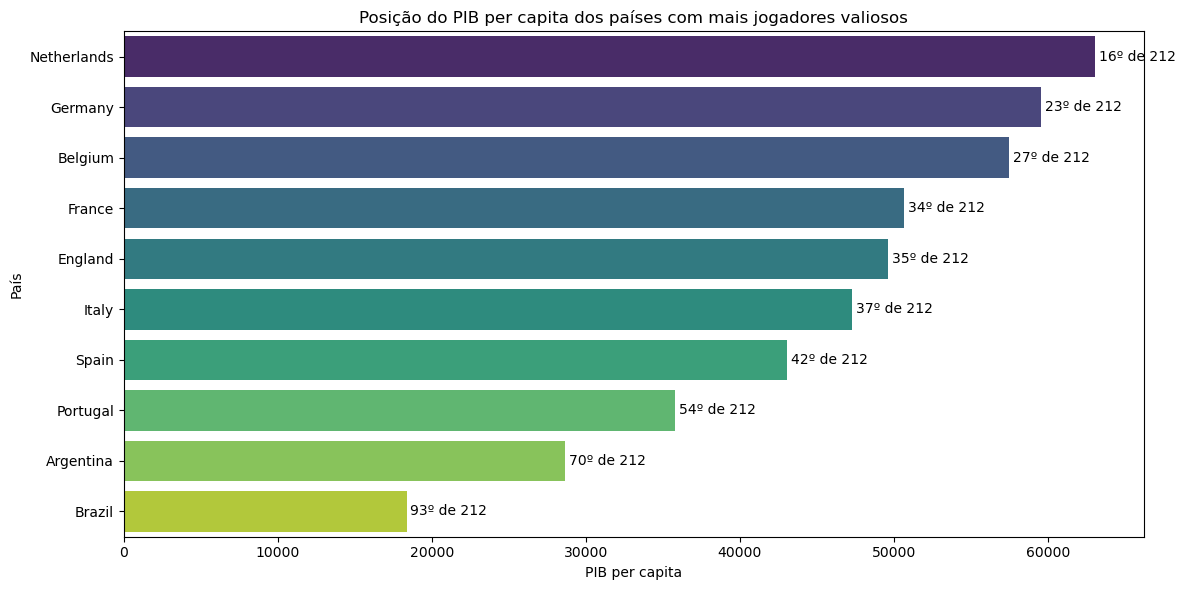

In [39]:
# Posição do PIB per capita dos países selecionados em relação a todos os países do dataset (2015)
pib_percapita = pd.read_csv(r"macrodata\gdp-per-capita-worldbank.csv")

paises_selecionados = ['France', 'Brazil', 'Spain', 'England', 'Germany', 'Argentina', 'Netherlands', 'Italy', 'Belgium', 'Portugal']

mapeamento = {'England': 'United Kingdom'}
nomes_dataset = [mapeamento.get(p, p) for p in paises_selecionados]

# Ranking global de todos os países em 2015
pib_global_2015 = (
    pib_percapita[pib_percapita['Year'] == 2015]
    .dropna(subset=['Entity', 'GDP per capita'])
    .sort_values('GDP per capita', ascending=False)
    .reset_index(drop=True)
)
pib_global_2015['Posição_Global'] = range(1, len(pib_global_2015) + 1)

# Filtra os países selecionados e mantém a ordem do gráfico anterior
pib_selecionados = (
    pib_global_2015[pib_global_2015['Entity'].isin(nomes_dataset)]
    .copy()
)
pib_selecionados['País'] = pib_selecionados['Entity'].replace({'United Kingdom': 'England'})
pib_selecionados = pib_selecionados[['País', 'GDP per capita', 'Posição_Global']]
# Mantém a mesma ordem visual do gráfico anterior (do maior para o menor PIB entre os países selecionados)
pib_selecionados = pib_selecionados.sort_values('GDP per capita', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=pib_selecionados, x='GDP per capita', y='País', palette='viridis', order=pib_selecionados['País'])
for i, row in pib_selecionados.iterrows():
    ax.text(row['GDP per capita'] + 250, i, f"{int(row['Posição_Global'])}º de {len(pib_global_2015)}", va='center', fontsize=10)

ax.set_title('Posição do PIB per capita dos países com mais jogadores valiosos')
ax.set_xlabel('PIB per capita')
ax.set_ylabel('País')
plt.tight_layout()
plt.show()